In [1]:
!pip install optuna
!pip install tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 34.3 MB/s eta 0:00:00


## 函式庫與資料集載入

In [2]:
import glob
import json
import os
import shutil

import numpy as np
import pandas as pd
import optuna
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Activation
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import RandomFlip
from tensorflow.keras.layers import RandomRotation
from tensorflow.keras.layers import RandomTranslation
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import load_model
from tensorflow.keras.datasets import cifar10


In [3]:
# 指定亂數種子
seed = 7
np.random.seed(seed)


In [4]:
# 載入 Cifar10 資料集, 如果是第一次載入會自行下載資料集
(X_train, Y_train), (X_test, Y_test) = cifar10.load_data()
Y_test_bk = Y_test.copy()   # 備份 Y_test 資料集


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 19s 0us/step


In [5]:
# 形狀
print("X_train.shape: ", X_train.shape)
print("Y_train.shape: ", Y_train.shape)
print("X_test.shape: ", X_test.shape)
print("Y_test.shape: ", Y_test.shape)


X_train.shape:  (50000, 32, 32, 3)
Y_train.shape:  (50000, 1)
X_test.shape:  (10000, 32, 32, 3)
Y_test.shape:  (10000, 1)


In [6]:
# 顯示 Numpy 二維陣列內容
print(X_train[0])
print(Y_train[0])   # 標籤資料


[[[ 59  62  63]
  [ 43  46  45]
  [ 50  48  43]
  ...
  [158 132 108]
  [152 125 102]
  [148 124 103]]

 [[ 16  20  20]
  [  0   0   0]
  [ 18   8   0]
  ...
  [123  88  55]
  [119  83  50]
  [122  87  57]]

 [[ 25  24  21]
  [ 16   7   0]
  [ 49  27   8]
  ...
  [118  84  50]
  [120  84  50]
  [109  73  42]]

 ...

 [[208 170  96]
  [201 153  34]
  [198 161  26]
  ...
  [160 133  70]
  [ 56  31   7]
  [ 53  34  20]]

 [[180 139  96]
  [173 123  42]
  [186 144  30]
  ...
  [184 148  94]
  [ 97  62  34]
  [ 83  53  34]]

 [[177 144 116]
  [168 129  94]
  [179 142  87]
  ...
  [216 184 140]
  [151 118  84]
  [123  92  72]]]
[6]


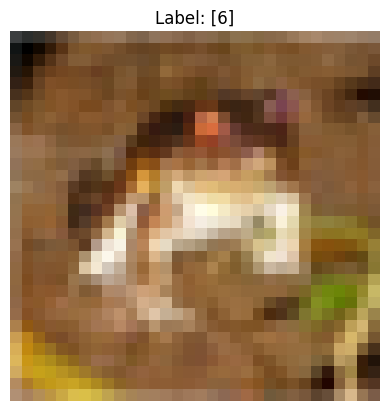

In [7]:
import matplotlib.pyplot as plt

plt.imshow(X_train[0], cmap="binary")
plt.title("Label: " + str(Y_train[0]))
plt.axis("off")
# 顯示圖片
plt.show()


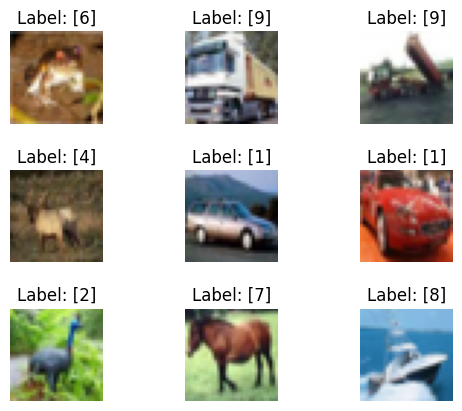

In [8]:
# 繪出9張圖片
sub_plot= 330
for i in range(0, 9):
    ax = plt.subplot(sub_plot+i+1)
    ax.imshow(X_train[i], cmap="binary")
    ax.set_title("Label: " + str(Y_train[i]))
    ax.axis("off")

plt.subplots_adjust(hspace = .5)
# 顯示數字圖片
plt.show()


## 圖檔前處理

In [9]:
# 因為是固定範圍, 所以執行正規化, 從 0-255 至 0-1
X_train = X_train.astype("float32") / 255
X_test = X_test.astype("float32") / 255
# One-hot編碼
Y_train = to_categorical(Y_train)
Y_test = to_categorical(Y_test)


## 使用 Optuna 搜尋 CNN 超參數


In [10]:
# 定義 Optuna 搜尋空間與 CNN 模型
SEARCH_LOG = "Ch3_3_4_optuna_search.json"
FINAL_MODEL = "413570012_20260522.keras"
KEEP_MODELS = {FINAL_MODEL, "413570012_HW5.keras", "413570012_20260424.keras", "413570012_0501.keras"}
N_TRIALS = 4
RUN_OPTUNA_SEARCH = True
BASE_SEED = seed + 22000

base = 2830
score_upperB = 100
score_lowerB = 80

if os.path.exists(SEARCH_LOG):
    with open(SEARCH_LOG) as f:
        trial_records = json.load(f)
else:
    trial_records = []

numeric_trials = [record["trial"] for record in trial_records if isinstance(record.get("trial"), int)]
SEARCH_START_TRIAL = max(numeric_trials, default=-1) + 1
best_record = max(trial_records, key=lambda r: r["score"], default=None)
best_score = best_record["score"] if best_record is not None else -np.inf
best_file = None
best_history = None


def make_optimizer(params):
    if params["optimizer"] == "rmsprop":
        return tf.keras.optimizers.RMSprop(learning_rate=params["learning_rate"])
    return tf.keras.optimizers.Adam(learning_rate=params["learning_rate"])


def add_conv_bn_relu(model, filters):
    model.add(Conv2D(filters, kernel_size=(3, 3), padding="same", use_bias=False))
    model.add(BatchNormalization())
    model.add(Activation("relu"))


def build_model_from_params(params):
    data_augmentation = Sequential(
        [
            RandomFlip("horizontal"),
            RandomTranslation(height_factor=0.05, width_factor=0.05),
            RandomRotation(0.03),
        ],
        name="data_augmentation",
    )

    model = Sequential()
    model.add(tf.keras.Input(shape=X_train.shape[1:]))
    model.add(data_augmentation)
    add_conv_bn_relu(model, params["filters_1"])
    if params["extra_conv_1"]:
        add_conv_bn_relu(model, params["filters_1"])
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Dropout(params["dropout_1"]))
    add_conv_bn_relu(model, params["filters_2"])
    if params["extra_conv_2"]:
        add_conv_bn_relu(model, params["filters_2"])
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Dropout(params["dropout_2"]))
    model.add(Flatten())
    model.add(Dense(params["dense_units"], use_bias=False))
    model.add(BatchNormalization())
    model.add(Activation("relu"))
    model.add(Dropout(params["dropout_dense"]))
    model.add(Dense(10, activation="softmax"))
    loss = tf.keras.losses.CategoricalCrossentropy(label_smoothing=params["label_smoothing"])
    model.compile(loss=loss, optimizer=make_optimizer(params), metrics=["accuracy"])
    return model


def suggest_params(trial):
    return {
        "filters_1": trial.suggest_categorical("filters_1", [32, 48, 64]),
        "filters_2": trial.suggest_categorical("filters_2", [64, 96, 128]),
        "extra_conv_1": trial.suggest_categorical("extra_conv_1", [False, True]),
        "extra_conv_2": trial.suggest_categorical("extra_conv_2", [False, True]),
        "dense_units": trial.suggest_categorical("dense_units", [256, 512, 640]),
        "dropout_1": trial.suggest_categorical("dropout_1", [0.2, 0.3, 0.4]),
        "dropout_2": trial.suggest_categorical("dropout_2", [0.3, 0.4, 0.5]),
        "dropout_dense": trial.suggest_categorical("dropout_dense", [0.3, 0.4, 0.5]),
        "optimizer": trial.suggest_categorical("optimizer", ["adam", "rmsprop"]),
        "learning_rate": trial.suggest_categorical("learning_rate", [0.0003, 0.0005, 0.001, 0.0015]),
        "label_smoothing": trial.suggest_categorical("label_smoothing", [0.0, 0.01, 0.02]),
        "epochs": trial.suggest_categorical("epochs", [30, 40, 50, 70, 80]),
        "batch_size": trial.suggest_categorical("batch_size", [64, 128, 256]),
        "validation_split": 0.2,
    }


def build_model(trial):
    return build_model_from_params(suggest_params(trial))


def score_model(model):
    y_pred_probs = model.predict(X_test, verbose=0)
    y_pred_classes = np.argmax(y_pred_probs, axis=1)
    y_true = Y_test_bk.flatten()
    df_error = pd.DataFrame({"label": y_true, "predict": y_pred_classes})
    df_error = df_error[y_true != y_pred_classes]
    wrong_count = len(df_error)
    score = 100 - ((score_upperB - score_lowerB) * (wrong_count / base))
    return float(score), int(wrong_count)


def trial_model_name(record):
    return (
        f"score_{record['score']:.6f}"
        f"_f1-{record['filters_1']}_f2-{record['filters_2']}"
        f"_x1-{int(record['extra_conv_1'])}_x2-{int(record['extra_conv_2'])}"
        f"_dense-{record['dense_units']}"
        f"_d1-{record['dropout_1']:.2f}_d2-{record['dropout_2']:.2f}_dd-{record['dropout_dense']:.2f}"
        f"_opt-{record['optimizer']}_lr-{record['learning_rate']}_ls-{record['label_smoothing']}"
        f"_bs-{record['batch_size']}_ep-{record['epochs']}_vs-{record['validation_split']}"
        f"_trial_{record['trial']:04d}.keras"
    )


def write_search_log():
    with open(SEARCH_LOG, "w") as f:
        json.dump(sorted(trial_records, key=lambda r: r["score"], reverse=True), f, indent=2)


In [11]:
# 定義 Optuna 目標函式：每次 trial 都保存 Keras 模型，並以 score 與參數命名。
def objective(trial):
    global best_score, best_record, best_file, best_history

    trial_id = SEARCH_START_TRIAL + trial.number
    seed_trial = BASE_SEED + trial_id
    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(seed_trial)

    params = suggest_params(trial)
    model = build_model_from_params(params)
    history_trial = model.fit(
        X_train,
        Y_train,
        validation_split=params["validation_split"],
        epochs=params["epochs"],
        batch_size=params["batch_size"],
        verbose=2,
        callbacks=[
            tf.keras.callbacks.EarlyStopping(
                monitor="val_accuracy",
                patience=8,
                restore_best_weights=True,
            ),
            tf.keras.callbacks.ReduceLROnPlateau(
                monitor="val_loss",
                factor=0.5,
                patience=4,
                min_lr=1e-6,
            ),
        ],
    )

    score, wrong_count = score_model(model)
    record = {
        "trial": trial_id,
        "score": score,
        "wrong_count": wrong_count,
        "seed": seed_trial,
        **params,
    }
    trial_file = trial_model_name(record)
    model.save(trial_file)
    record["file"] = trial_file
    trial_records.append(record)
    trial.set_user_attr("file", trial_file)
    trial.set_user_attr("score_record", record)

    if score > best_score:
        best_score = score
        best_record = record
        best_file = trial_file
        best_history = history_trial
        print("NEW_BEST", json.dumps(record, ensure_ascii=False))

    write_search_log()
    return score


In [12]:
# 準備 Optuna 搜尋，並載入分數最高的 CNN 模型
if os.path.exists(SEARCH_LOG):
    with open(SEARCH_LOG) as f:
        trial_records = json.load(f)
else:
    trial_records = []

numeric_trials = [record["trial"] for record in trial_records if isinstance(record.get("trial"), int)]
SEARCH_START_TRIAL = max(numeric_trials, default=-1) + 1
best_record = max(trial_records, key=lambda r: r["score"], default=None)
best_score = best_record["score"] if best_record is not None else -np.inf
best_file = None
best_history = None

for path in glob.glob("score_*.keras"):
    os.remove(path)

if os.path.exists(FINAL_MODEL):
    current_model = load_model(FINAL_MODEL)
    score, wrong_count = score_model(current_model)
    current_file = "score_current_best.keras"
    current_model.save(current_file)
    current_record = {
        "trial": "current_after_trial_{}".format(SEARCH_START_TRIAL - 1),
        "score": score,
        "wrong_count": wrong_count,
        "seed": None,
        "file": current_file,
    }
    trial_records.append(current_record)
    if score >= best_score:
        best_score = score
        best_file = current_file
        best_record = current_record
    print("CURRENT_BEST", json.dumps(current_record, ensure_ascii=False))

sampler = optuna.samplers.TPESampler(seed=BASE_SEED, n_startup_trials=1)
study = optuna.create_study(direction="maximize", sampler=sampler)

# 依目前搜尋結果調整下一輪候選參數, 最多保留 4 組。
top_trial_params = [
    {"filters_1": 64, "filters_2": 128, "extra_conv_1": True, "extra_conv_2": True, "dense_units": 640, "dropout_1": 0.2, "dropout_2": 0.3, "dropout_dense": 0.3, "optimizer": "adam", "learning_rate": 0.0005, "label_smoothing": 0.01, "epochs": 70, "batch_size": 64},
    {"filters_1": 64, "filters_2": 128, "extra_conv_1": True, "extra_conv_2": True, "dense_units": 640, "dropout_1": 0.3, "dropout_2": 0.4, "dropout_dense": 0.3, "optimizer": "adam", "learning_rate": 0.0005, "label_smoothing": 0.01, "epochs": 70, "batch_size": 64},
    {"filters_1": 64, "filters_2": 128, "extra_conv_1": True, "extra_conv_2": True, "dense_units": 640, "dropout_1": 0.2, "dropout_2": 0.3, "dropout_dense": 0.3, "optimizer": "adam", "learning_rate": 0.0003, "label_smoothing": 0.01, "epochs": 80, "batch_size": 64},
    {"filters_1": 64, "filters_2": 128, "extra_conv_1": True, "extra_conv_2": True, "dense_units": 640, "dropout_1": 0.2, "dropout_2": 0.3, "dropout_dense": 0.3, "optimizer": "adam", "learning_rate": 0.0005, "label_smoothing": 0.01, "epochs": 80, "batch_size": 128},
]

for params in top_trial_params[:N_TRIALS]:
    study.enqueue_trial(params)

if RUN_OPTUNA_SEARCH:
    study.optimize(objective, n_trials=N_TRIALS)
else:
    print(f"Optuna search is prepared but not started. RUN_OPTUNA_SEARCH={RUN_OPTUNA_SEARCH}, N_TRIALS={N_TRIALS}")
    print("Best searched params =", top_trial_params[0])

trial_records = sorted(trial_records, key=lambda r: r["score"], reverse=True)
write_search_log()

best_record = trial_records[0]
if best_file is None and os.path.exists(best_record.get("file", "")):
    best_file = best_record["file"]
elif best_file is None and os.path.exists(FINAL_MODEL):
    best_file = FINAL_MODEL
print("Best score = {:.4f}".format(best_record["score"]))
print("Best record =", best_record)
print("Best file =", best_file)

model = load_model(best_file)
history = best_history

if history is None:
    class EmptyHistory:
        history = {
            "loss": [np.nan],
            "val_loss": [np.nan],
            "accuracy": [np.nan],
            "val_accuracy": [np.nan],
        }
    history = EmptyHistory()
else:
    n = len(history.history.get("loss", []))
    if "val_loss" not in history.history:
        history.history["val_loss"] = [np.nan] * n
    if "val_accuracy" not in history.history:
        history.history["val_accuracy"] = [np.nan] * n

model.summary()   # 顯示模型摘要資訊


[I 2026-05-14 05:43:16,760] A new study created in memory with name: no-name-0e65cbd1-7c53-49c3-b18a-8fd3d6bf9ebe


CURRENT_BEST {"trial": "current_after_trial_8", "score": 87.7243816254417, "wrong_count": 1737, "seed": null, "file": "score_current_best.keras"}
Epoch 1/70
625/625 - 27s - 43ms/step - accuracy: 0.4822 - loss: 1.5056 - val_accuracy: 0.4323 - val_loss: 1.8163 - learning_rate: 5.0000e-04
Epoch 2/70
625/625 - 20s - 31ms/step - accuracy: 0.6205 - loss: 1.1042 - val_accuracy: 0.6160 - val_loss: 1.1791 - learning_rate: 5.0000e-04
Epoch 3/70
625/625 - 19s - 30ms/step - accuracy: 0.6836 - loss: 0.9430 - val_accuracy: 0.6843 - val_loss: 0.9530 - learning_rate: 5.0000e-04
Epoch 4/70
625/625 - 19s - 31ms/step - accuracy: 0.7171 - loss: 0.8511 - val_accuracy: 0.7106 - val_loss: 0.8906 - learning_rate: 5.0000e-04
Epoch 5/70
625/625 - 19s - 30ms/step - accuracy: 0.7429 - loss: 0.7879 - val_accuracy: 0.7435 - val_loss: 0.7961 - learning_rate: 5.0000e-04
Epoch 6/70
625/625 - 19s - 31ms/step - accuracy: 0.7605 - loss: 0.7395 - val_accuracy: 0.7424 - val_loss: 0.7965 - learning_rate: 5.0000e-04
Epoch 7/

[I 2026-05-14 06:02:21,119] Trial 0 finished with value: 90.82685512367492 and parameters: {'filters_1': 64, 'filters_2': 128, 'extra_conv_1': True, 'extra_conv_2': True, 'dense_units': 640, 'dropout_1': 0.2, 'dropout_2': 0.3, 'dropout_dense': 0.3, 'optimizer': 'adam', 'learning_rate': 0.0005, 'label_smoothing': 0.01, 'epochs': 70, 'batch_size': 64}. Best is trial 0 with value: 90.82685512367492.


NEW_BEST {"trial": 9, "score": 90.82685512367492, "wrong_count": 1298, "seed": 22016, "filters_1": 64, "filters_2": 128, "extra_conv_1": true, "extra_conv_2": true, "dense_units": 640, "dropout_1": 0.2, "dropout_2": 0.3, "dropout_dense": 0.3, "optimizer": "adam", "learning_rate": 0.0005, "label_smoothing": 0.01, "epochs": 70, "batch_size": 64, "validation_split": 0.2, "file": "score_90.826855_f1-64_f2-128_x1-1_x2-1_dense-640_d1-0.20_d2-0.30_dd-0.30_opt-adam_lr-0.0005_ls-0.01_bs-64_ep-70_vs-0.2_trial_0009.keras"}
Epoch 1/70
625/625 - 23s - 37ms/step - accuracy: 0.4681 - loss: 1.5396 - val_accuracy: 0.4420 - val_loss: 1.6852 - learning_rate: 5.0000e-04
Epoch 2/70
625/625 - 19s - 31ms/step - accuracy: 0.6070 - loss: 1.1429 - val_accuracy: 0.6164 - val_loss: 1.1919 - learning_rate: 5.0000e-04
Epoch 3/70
625/625 - 19s - 31ms/step - accuracy: 0.6669 - loss: 0.9773 - val_accuracy: 0.5698 - val_loss: 1.4201 - learning_rate: 5.0000e-04
Epoch 4/70
625/625 - 19s - 31ms/step - accuracy: 0.7018 - l

[I 2026-05-14 06:22:05,982] Trial 1 finished with value: 90.75618374558304 and parameters: {'filters_1': 64, 'filters_2': 128, 'extra_conv_1': True, 'extra_conv_2': True, 'dense_units': 640, 'dropout_1': 0.3, 'dropout_2': 0.4, 'dropout_dense': 0.3, 'optimizer': 'adam', 'learning_rate': 0.0005, 'label_smoothing': 0.01, 'epochs': 70, 'batch_size': 64}. Best is trial 0 with value: 90.82685512367492.


...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 64)     │         1,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 128)    │       147,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 640)            │     5,242,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 640)            │         2,560 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 640)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 640)            │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 16,535,392 (63.08 MB)

 Trainable params: 5,511,114 (21.02 MB)

 Non-trainable params: 2,048 (8.00 KB)

 Optimizer params: 11,022,230 (42.05 MB)

In [13]:
# 評估模型
print("\nTesting ...")
loss, accuracy = model.evaluate(X_train, Y_train, verbose=0)
print("訓練資料集的準確度 = {:.4f}".format(accuracy))
loss, accuracy = model.evaluate(X_test, Y_test, verbose=0)
print("測試資料集的準確度 = {:.4f}".format(accuracy))



Testing ...
訓練資料集的準確度 = 0.9639
測試資料集的準確度 = 0.8702


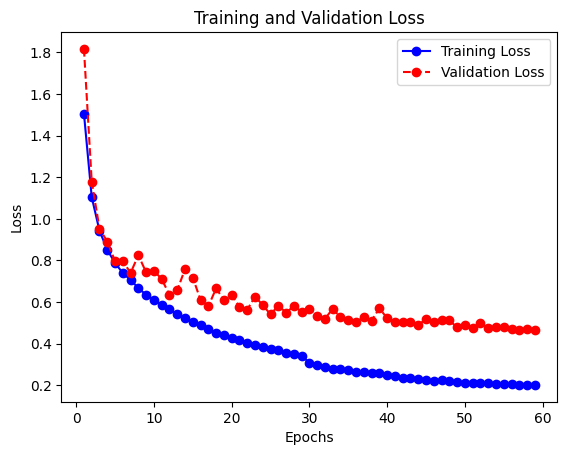

In [14]:
# 顯示圖表來分析模型的訓練過程
# 顯示訓練和驗證損失
loss = history.history["loss"]
epochs = range(1, len(loss)+1)
val_loss = history.history["val_loss"]
plt.plot(epochs, loss, "bo-", label="Training Loss")
plt.plot(epochs, val_loss, "ro--", label="Validation Loss")
plt.title("Training and Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()


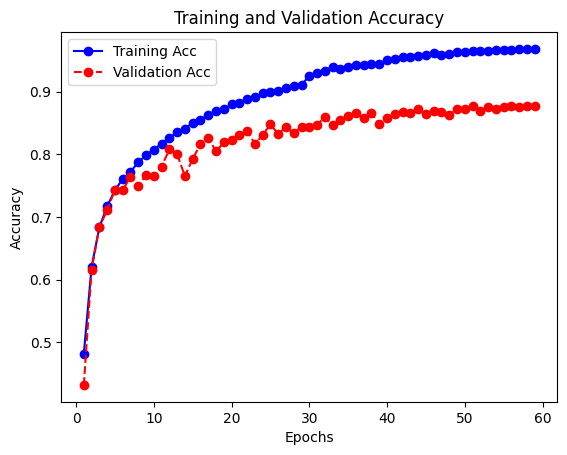

In [15]:
# 顯示訓練和驗證準確度
acc = history.history["accuracy"]
epochs = range(1, len(acc)+1)
val_acc = history.history["val_accuracy"]
plt.plot(epochs, acc, "bo-", label="Training Acc")
plt.plot(epochs, val_acc, "ro--", label="Validation Acc")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


In [16]:
# 計算分類的預測值
print("\nPredicting ...")
Y_pred = model.predict(X_test)
Y_pred_classes=np.argmax(Y_pred,axis=1)

# 顯示混淆矩陣
tb = pd.crosstab(Y_test_bk.astype(int).flatten(), Y_pred_classes.astype(int), rownames=["label"], colnames=["predict"])
print(tb)



Predicting ...
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
predict    0    1    2    3    4    5    6    7    8    9
label                                                    
0        903    7   21    5    8    1    8    4   20   23
1          5  956    0    1    3    0    1    1    5   28
2         36    1  813   14   36   22   52   19    2    5
3         19    6   42  678   41   99   66   23    6   20
4          5    1   24   14  878   16   45   15    2    0
5          9    3   24   89   35  763   37   30    3    7
6          4    1   11    8    9    2  959    2    3    1
7          3    0   13   14   24   12    8  920    1    5
8         41   14    8    3    3    1    2    1  906   21
9         11   44    2    3    2    0    3    2    7  926


In [ ]:
# 儲存最佳 CNN Keras 模型，並清理非保留的 Keras 模型
model.save(FINAL_MODEL)

for path in glob.glob("*.keras"):
    filename = os.path.basename(path)
    if filename not in KEEP_MODELS:
        os.remove(path)


## 模型推論，辨識照片是十種分類中的哪一類

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 286ms/step


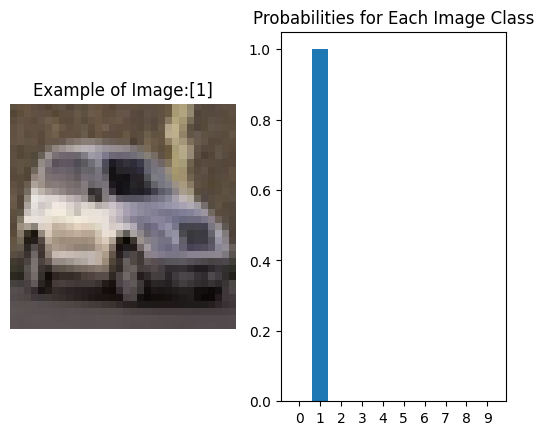

In [18]:
# 隨機選一張測試的圖片
i = np.random.randint(0, len(X_test))
img = X_test[i]
# 將圖片轉換成 4D 張量
X_test_img = img.reshape(1, 32, 32, 3).astype("float32")
# 建立Keras的Sequential模型
model_inference = Sequential()
model_inference = load_model(FINAL_MODEL)
# 編譯模型
model_inference.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])
# 模型對圖片進行辨識
Y_pred_probs = model_inference.predict(X_test_img)

# 繪出圖片與其分類答案
plt.figure()
plt.subplot(1,2,1)
plt.title("Example of Image:" + str(Y_test_bk[i]))
plt.imshow(img, cmap="binary")
plt.axis("off")

# 預測結果的機率
plt.subplot(1,2,2)
plt.title("Probabilities for Each Image Class")
plt.bar(np.arange(10), Y_pred_probs.reshape(10), align="center")
plt.xticks(np.arange(10),np.arange(10).astype(str))
plt.show()


## 檢查辨識錯誤的圖檔

In [19]:
# 測試資料集的分類和機率的預測值
Y_pred_probs = model_inference.predict(X_test)     # 預測機率
Y_pred_classes= np.argmax(Y_pred_probs,axis=1)   # 轉成分類

Y_test_fl = Y_test_bk.flatten() # 標準答案的資料格式轉換成一維


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [20]:
# 建立分類錯誤的 DataFrame 物件
df = pd.DataFrame({"label":Y_test_fl, "predict":Y_pred_classes})
df = df[Y_test_fl!=Y_pred_classes]  # 篩選出分類錯誤的資料
print(df.head()) # 看前五筆分類錯誤


    label  predict
24      5        4
25      2        4
37      1        9
42      5        3
52      0        9


In [21]:
len(df)


1298

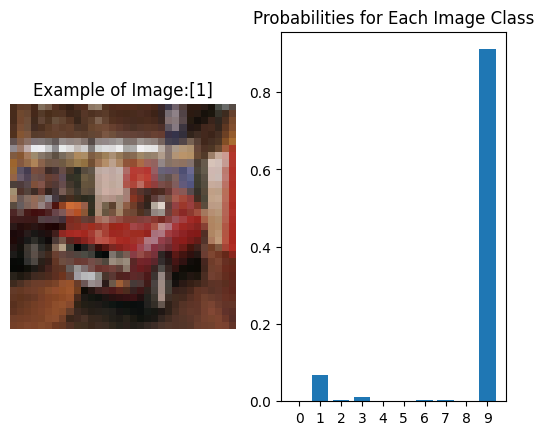

In [22]:
# 隨機選1個錯誤分類的數字索引
i = df.sample(n=1).index.values.astype(int)[0]
img = X_test[i]

# 繪出圖片與其分類答案
plt.figure()
plt.subplot(1,2,1)
plt.title("Example of Image:" + str(Y_test_bk[i]))
plt.imshow(img, cmap="binary")
plt.axis("off")

# 預測結果的機率
plt.subplot(1,2,2)
plt.title("Probabilities for Each Image Class")
plt.bar(np.arange(10), Y_pred_probs[i].reshape(10), align="center")
plt.xticks(np.arange(10),np.arange(10).astype(str))
plt.show()


In [23]:
# 預測錯誤的筆數
len(df)


1298

In [24]:
# 作業計算公式
base = 2830
score_upperB = 100
score_lowerB = 80
score = 100-((score_upperB-score_lowerB)*(len(df)/base))

print(score)


90.82685512367492
